<a href="https://colab.research.google.com/github/maggiecrowner/DS5001-Final-Project/blob/main/Sentiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment

In [1]:
! git clone https://github.com/maggiecrowner/DS5001-Final-Project.git

Cloning into 'DS5001-Final-Project'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (21/21), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 196 (delta 11), reused 4 (delta 4), pack-reused 175 (from 1)
Receiving objects: 100% (196/196), 12.87 MiB | 9.46 MiB/s, done.
Resolving deltas: 100% (62/62), done.


In [2]:
!wget -O VOCAB.csv "https://virginia.box.com/shared/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv"
!wget -O BOW.csv "https://virginia.box.com/shared/static/jnjmet326j10jijnzwjcj87n35dfjkwl.csv"
!wget -O LIB.csv "https://virginia.box.com/shared/static/fhzudg34je9xls5bfcbi4xdnaiek74rj.csv"

--2026-04-20 12:50:45--  https://virginia.box.com/shared/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv
Resolving virginia.box.com (virginia.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.box.com (virginia.box.com)|74.112.186.157|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: /public/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv [following]
--2026-04-20 12:50:45--  https://virginia.box.com/public/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv
Reusing existing connection to virginia.box.com:443.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://virginia.app.box.com/public/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv [following]
--2026-04-20 12:50:45--  https://virginia.app.box.com/public/static/a2njs9ipjxrgam9un7sr4yn3f6f196ny.csv
Resolving virginia.app.box.com (virginia.app.box.com)... 74.112.186.157, 2620:117:bff0:12d::
Connecting to virginia.app.box.com (virginia.app.box.com)|74.112.186.157|:443.

In [3]:
! pip install afinn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for afinn: filename=afinn-0.1-py3-none-any.whl size=53431 sha256=19351f015992338dc245694dd4a78076dad944ca43a9791d122be77e5f4fdf93
  Stored in directory: /root/.cache/pip/wheels/f9/72/27/74994e77200dae3d6aea2b546264500cee21f738c51241320b
Successfully built afinn


In [4]:
import pandas as pd
import re
from afinn import Afinn

In [5]:
VOCAB = pd.read_csv('VOCAB.csv', delimiter='|', index_col="term_str")
BOW = pd.read_csv('BOW.csv', delimiter='|', index_col=["Artist", "Album", "Title", "term_str"])
LIB = pd.read_csv('LIB.csv', delimiter='|', index_col=0)

## VOCAB_SENT

In [6]:
afinn = Afinn()
VOCAB.index = VOCAB.index.astype(str)
VOCAB = VOCAB[VOCAB.index.notna()]
VOCAB = VOCAB[VOCAB.index != "NaN"]

VOCAB["sentiment_score"] = VOCAB.index.map(lambda w: afinn.score(w))

VOCAB_SENT = (
    VOCAB[VOCAB["sentiment_score"] != 0][["sentiment_score"]]
    .copy()
    .reset_index()
    .rename(columns={"term_str": "term_str"})
    .set_index("term_str")
)

In [7]:
VOCAB_SENT.head()

,sentiment_score
term_str,
abandoned,-2.0
ability,2.0
aboard,1.0
abuse,-3.0
accept,1.0


In [8]:
VOCAB_SENT.to_csv("/content/DS5001-Final-Project/VOCAB_SENT.csv", sep="|", index=True)

## BOW_SENT

In [9]:
BOW.index = BOW.index.set_levels(BOW.index.levels[-1].astype(str), level="term_str")
BOW = BOW[BOW.index.get_level_values("term_str").notna()]
BOW = BOW[BOW.index.get_level_values("term_str") != "NaN"]

BOW_SENT = (
    BOW
    .join(VOCAB_SENT[["sentiment_score"]], on="term_str", how="inner")
)

BOW_SENT["sentiment_weighted"] = BOW_SENT["sentiment_score"] * BOW_SENT["n"]

In [10]:
BOW_SENT.head()

n  \
Artist        Album                                 Title         term_str      
Ariana Grande 13 (Original Broadway Cast Recording) Brand New You better    1   
                                                                  big       2   
                                                                  great     2   
                                                                  hide      1   
                                                                  no        1   

                                                                            sentiment_score  \
Artist        Album                                 Title         term_str                    
Ariana Grande 13 (Original Broadway Cast Recording) Brand New You better                2.0   
                                                                  big                   1.0   
                                                                  great                 3.0   
                                                                  hide                 -1.0   
                                                                  no                   -1.0   

                                                                            sentiment_weighted  
Artist        Album                                 Title         term_str                      
Ariana Grande 13 (Original Broadway Cast Recording) Brand New You better                   2.0  
                                                                  big                      2.0  
                                                                  great                    6.0  
                                                                  hide                    -1.0  
                                                                  no                      -1.0

In [11]:
BOW_SENT.to_csv("/content/DS5001-Final-Project/BOW_SENT.csv", sep="|", index=True)

## DOC_SENT

In [12]:
DOC_SENT = (
    BOW_SENT
    .groupby(["Artist", "Album", "Title"])
    .agg(
        sentiment_sum    = ("sentiment_weighted", "sum"),
        sentiment_mean   = ("sentiment_weighted", "mean"),
        sentiment_tokens = ("n", "sum"),
    )
    .reset_index()
)

DOC_SENT["sentiment_norm"] = DOC_SENT["sentiment_sum"] / DOC_SENT["sentiment_tokens"]

In [13]:
DOC_SENT.head()

,Artist,Album,Title,sentiment_sum,sentiment_mean,sentiment_tokens,sentiment_norm
0,Ariana Grande,13 (Original Broadway Cast Recording),Brand New You,9.0,1.125000,10,0.90
1,Ariana Grande,Ariana Grande,Ariana Grande Tour Guide,-4.0,-1.000000,5,-0.80
2,Ariana Grande,Ariana Grande,I’m Every Woman/Vogue,7.0,0.411765,28,0.25
3,Ariana Grande,Ariana Grande,Leave Me Lonely (Reprise),-18.0,-2.571429,18,-1.00
4,Ariana Grande,Ariana Grande,Love Me Harder/breathin,18.0,1.800000,20,0.90


In [14]:
DOC_SENT.to_csv("/content/DS5001-Final-Project/DOC_SENT.csv", sep="|", index=True)

## Sentiment Plot

In [15]:
DOC_SENT = DOC_SENT.merge(
    LIB[["Artist", "Album", "Title", "Year"]],
    on=["Artist", "Album", "Title"],
    how="left"
)

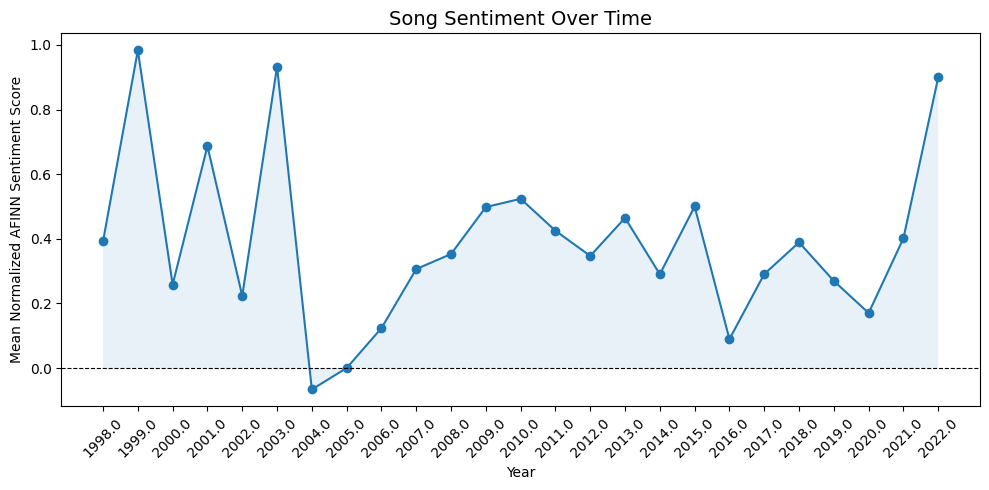

In [16]:
import matplotlib.pyplot as plt

year_sent = (
    DOC_SENT
    .dropna(subset=["Year"])
    .groupby("Year")["sentiment_norm"]
    .mean()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(year_sent.index.astype(str), year_sent.values, marker="o")
ax.fill_between(range(len(year_sent)), year_sent.values, alpha=0.1)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Song Sentiment Over Time", fontsize=14)
ax.set_xlabel("Year")
ax.set_ylabel("Mean Normalized AFINN Sentiment Score")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("sentiment_plot.png", dpi=150)
plt.show()